# Task 3: Cleaning Data

## Objective

The objective of this project is to demonstrate professional data cleaning skills by systematically transforming a messy dataset into a clean, analysis-ready dataset.

The cleaning process includes identifying and handling missing values, removing duplicate records, standardizing inconsistent data, detecting outliers, correcting data types, and comparing the dataset before and after cleaning.

## Tools Used

- Python
- Pandas
- NumPy
- Jupyter Notebook

## Import libraries

In [4]:
import pandas as pd
import numpy as np

## Dataset Loading

In [5]:
df = pd.read_csv('/content/train.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Initial Data Inspection

In [6]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


## Data Quality Assessment

In [7]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows:
0


## Data Quality Report

The dataset contains 891 rows and 12 columns.

The initial inspection identified missing values in three columns:

- **Age:** 177 missing values
- **Cabin:** 687 missing values
- **Embarked:** 2 missing values

No duplicate rows were identified in the dataset.

The remaining columns do not contain missing values. The data types were also inspected to identify columns that may require correction during the cleaning process.

## Numerical Data Quality Findings

In [8]:
print("Numerical columns summary:")
display(df.describe())

Numerical columns summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Numerical Data Quality Findings

The numerical summary shows that most numerical columns contain values within reasonable ranges.

- `Age` ranges from 0.42 to 80 years, with 177 missing values.
- `Fare` ranges from 0 to 512.33 and may contain statistical outliers that require further investigation.
- `SibSp` ranges from 0 to 8.
- `Parch` ranges from 0 to 6.
- `Survived` contains binary values (0 and 1).
- `Pclass` contains the expected class values (1, 2, and 3).
- `PassengerId` is an identifier and will not be considered for outlier analysis.

Further outlier investigation will be performed using the IQR method.

## Categorical Data Findings

In [9]:
print("Unique values in Sex:")
print(df['Sex'].unique())

print("\nUnique values in Embarked:")
print(df['Embarked'].unique())

print("\nUnique values in Pclass:")
print(df['Pclass'].unique())

Unique values in Sex:
['male' 'female']

Unique values in Embarked:
['S' 'C' 'Q' nan]

Unique values in Pclass:
[3 1 2]


## Categorical Data Findings

The categorical columns were inspected for inconsistent formatting and unexpected values.

- `Sex` contains only `male` and `female`, with consistent formatting.
- `Embarked` contains the valid categories `S`, `C`, and `Q`, along with 2 missing values.
- `Pclass` contains the expected values 1, 2, and 3.

No inconsistent categorical formatting was identified. The missing values in `Embarked` will be handled separately.

## Missing Data Handling

In [10]:
missing_before = df.isnull().sum()

missing_summary = pd.DataFrame({
    'Missing Values': missing_before,
    'Missing Percentage': (missing_before / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Missing Percentage
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


## Missing Data Handling Strategy

The following strategies were selected based on the amount and nature of missing data:

- **Age:** The 177 missing values (19.87%) will be replaced using the median age. Median imputation is preferred because it is less affected by extreme age values than the mean.

- **Embarked:** The 2 missing values (0.22%) will be replaced using the mode because this is a categorical variable and the missing proportion is very small.

- **Cabin:** The Cabin column has 687 missing values (77.10%). Since most observations are missing, reliable imputation would not be appropriate. Therefore, the column will be removed from the analysis.

These decisions are documented before applying the cleaning operations.

## Duplicate Detection and Removal

In [26]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Duplicate Data Handling

The dataset was checked for duplicate rows during the initial data quality assessment.

A total of **0 duplicate rows** were identified. Therefore, no rows were removed during the duplicate-cleaning step.

This confirms that the dataset did not contain duplicate records requiring removal.

## Data Standardisation

In [20]:
df['Sex'] = df['Sex'].str.strip().str.title()

print(df['Sex'].value_counts())

Sex
Male      577
Female    314
Name: count, dtype: int64


## Data Type Validation

In [12]:
print("Data types after cleaning:")
print(df.dtypes)

Data types after cleaning:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


## Data Type Validation

The data types of all columns were reviewed after the missing-value cleaning process.

The numerical columns have appropriate integer or floating-point data types, while categorical and text columns are stored as object data types.

No major data type inconsistencies were identified, so no additional type conversion was required.

## Outlier Detection

In [13]:
numeric_cols = ['Age', 'SibSp', 'Parch', 'Fare']

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    }

outlier_summary = pd.DataFrame(outlier_summary).T

outlier_summary

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
Age,22.0000,35.0,13.0000,2.500,54.5000,66.0
SibSp,0.0000,1.0,1.0000,-1.500,2.5000,46.0
Parch,0.0000,0.0,0.0000,0.000,0.0000,213.0
Fare,7.9104,31.0,23.0896,-26.724,65.6344,116.0


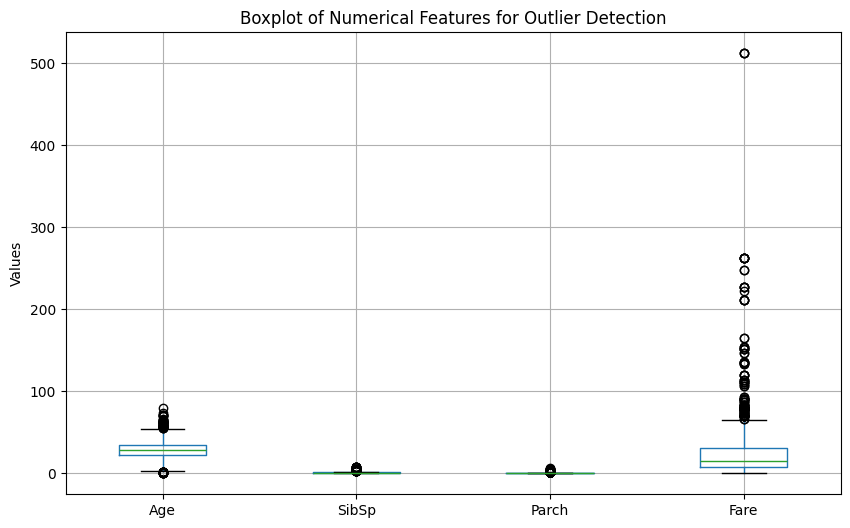

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df[['Age', 'SibSp', 'Parch', 'Fare']].boxplot()

plt.title("Boxplot of Numerical Features for Outlier Detection")
plt.ylabel("Values")
plt.xticks(rotation=0)
plt.show()

## Outlier Detection and Handling

The IQR method was used to identify statistical outliers in the numerical columns.

The detected outliers were:

- **Age:** 66
- **SibSp:** 46
- **Parch:** 213
- **Fare:** 116

These observations were reviewed as statistical outliers rather than automatically treating them as errors. Values such as higher fares, larger family sizes, and older passenger ages can represent legitimate real-world observations.

Therefore, the identified outliers were **retained** rather than removed or capped. This prevents the loss of potentially meaningful information from the dataset.

## Final Data Verification

In [27]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (891, 11)

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Duplicate Rows: 0


In [15]:
print("Final Data Types:\n")
print(df.dtypes)

Final Data Types:

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


## Before vs After Cleaning Summary

In [29]:
summary = pd.DataFrame({
    'Metric': [
        'Row Count',
        'Column Count',
        'Total Missing Values',
        'Duplicate Rows'
    ],
    'Before Cleaning': [
        891,
        12,
        866,
        0
    ],
    'After Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

display(summary)

,Metric,Before Cleaning,After Cleaning
0,Row Count,891,891
1,Column Count,12,11
2,Total Missing Values,866,0
3,Duplicate Rows,0,0


## Before vs After Cleaning Summary

The following table summarizes the key changes made during the data cleaning process, including row count, column count, missing values, and duplicate records.

## Export Cleaned Dataset

In [16]:
df.to_csv("Titanic_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [17]:
import os

print("File exists:", os.path.exists("Titanic_Cleaned.csv"))

File exists: True


## Conclusion

Conclusion: The Titanic dataset was successfully cleaned and transformed into an analysis-ready dataset. The cleaning process included assessing data quality, handling missing values using appropriate imputation techniques, removing the Cabin column due to extensive missing data, checking and removing duplicate records, standardising categorical values, validating data types, and identifying potential outliers using the IQR method. The detected outliers were reviewed and retained where they represented valid passenger characteristics. After cleaning, the dataset contained 891 rows and 11 columns, with zero missing values and zero duplicate records. The cleaned dataset was then exported as a new CSV file for further analysis.